# MFDFA validation on synthetic signals

`pdeeg.features.mfdfa` is run here on six signals whose scaling exponents are known exactly, with
the parameters in `configs/features/mfdfa.yaml`. Nothing in this notebook touches EEG.

| Signal | Exact result |
|---|---|
| Fractional Gaussian noise, $H$ = 0.3, 0.7, 0.9 | $h(q) = H$ for every $q$; the spectrum is the single point $(H, 1)$ |
| White noise | the same, with $H = 0.5$ |
| Random walk (cumulative white noise) | the same, with $H = 1.5$ |
| Binomial cascade, $a = 0.75$ | $\tau(q) = -\log_2(a^q + (1 - a)^q)$ and $h(q) = (\tau(q) + 1) / q$, which falls from 1.80 at $q = -5$ to 0.61 at $q = 5$; the spectrum is 1.57 wide |

The sections plot the fluctuation functions, $h(q)$ and $f(\alpha)$ for one realisation of each
signal, compare the features with theory, look at how the cascade depends on the choice of scales,
and measure the bias and spread of the estimates over many realisations. That last table is what
the tolerances in `tests/test_mfdfa.py` are based on.

To re-run: `jupyter execute --inplace notebooks/01_mfdfa_validation.ipynb` (about a minute). Keep
this notebook to ASCII characters: on Windows that command reads it in the locale encoding.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

from pdeeg.config import load_config
from pdeeg.features.mfdfa import make_qs, make_scales, mfdfa, spectrum_features
from pdeeg.features.synthetic import binomial_cascade, binomial_cascade_spectrum, fgn

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs").is_dir())
config = load_config(root / "configs").mfdfa

N_LEVELS = 16  # every signal has 2**16 = 65536 samples, about one 180 s recording at 512 Hz
N_SAMPLES = 2**N_LEVELS
CASCADE_A = 0.75
SEED = 2002

qs = make_qs(config.q_min, config.q_max, config.q_step)
scales = make_scales(N_SAMPLES, config.scale_min, config.scale_max_frac, config.n_scales)


def analyse(x, scales=scales, fit_range=config.fit_range):
    return mfdfa(
        x,
        scales,
        qs,
        order=config.detrend_order,
        fit_range=fit_range,
        min_variance_ratio=config.min_variance_ratio,
    )


print(f"q: {qs[0]:g} to {qs[-1]:g} in steps of {config.q_step:g} ({qs.size} values)")
print(f"scales: {scales.size} from {scales[0]} to {scales[-1]} samples, of {N_SAMPLES}")
print(f"detrending order {config.detrend_order}, fit range {config.fit_range or 'all scales'}")

q: -5 to 5 in steps of 0.5 (21 values)
scales: 20 from 16 to 6553 samples, of 65536
detrending order 1, fit range all scales


## Signals

One realisation of each, in order of increasing Hurst exponent. A monofractal signal has the same
exponent at every $q$, so its exact spectrum is a single point.

In [2]:
def monofractal(hurst):
    # Exact h(q), alpha(q) and f(alpha(q)) of a monofractal signal.
    return np.full(qs.size, hurst), np.full(qs.size, hurst), np.ones(qs.size)


def noise():
    return np.random.default_rng(SEED).standard_normal(N_SAMPLES)


signals = {
    "fGn, H = 0.3": (fgn(N_SAMPLES, 0.3, np.random.default_rng(SEED)), monofractal(0.3)),
    "White noise": (noise(), monofractal(0.5)),
    "fGn, H = 0.7": (fgn(N_SAMPLES, 0.7, np.random.default_rng(SEED)), monofractal(0.7)),
    "fGn, H = 0.9": (fgn(N_SAMPLES, 0.9, np.random.default_rng(SEED)), monofractal(0.9)),
    "Random walk": (np.cumsum(noise()), monofractal(1.5)),
    "Binomial cascade": (
        binomial_cascade(N_LEVELS, CASCADE_A),
        binomial_cascade_spectrum(qs, CASCADE_A),
    ),
}
results = {name: analyse(x) for name, (x, _) in signals.items()}
theory = {name: exact for name, (_, exact) in signals.items()}

In [3]:
# Figure style: one colour per signal, in a fixed order; grey for theory; text in ink colours.
SURFACE, INK, INK_SECONDARY, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
COLOR = dict(zip(signals, SERIES, strict=True))
Q_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # light to dark: low to high q
THEORY = INK_SECONDARY
ALPHA = chr(0x3B1)  # the Greek letter, spelled so that this file stays ASCII

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.family": "sans-serif",
        "font.sans-serif": ["Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
        "font.size": 10,
        "text.color": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "axes.titlelocation": "left",
        "axes.labelcolor": INK_SECONDARY,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_SECONDARY,
        "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False,
    }
)
DOT = {"marker": "o", "ms": 5.5, "mec": SURFACE, "mew": 0.9, "ls": "none"}

## Fluctuation functions

Each panel shows $F_q(s)$ for five moment orders, with the fitted power law drawn over the scales
that entered the fit. Every panel spans the same number of decades, so a steeper line is a larger
exponent in any of them; the vertical position differs between panels because the signals have
different amplitudes.

For a monofractal signal the five lines are parallel. For the cascade they fan out: small
fluctuations (negative $q$) grow faster with scale than large ones.

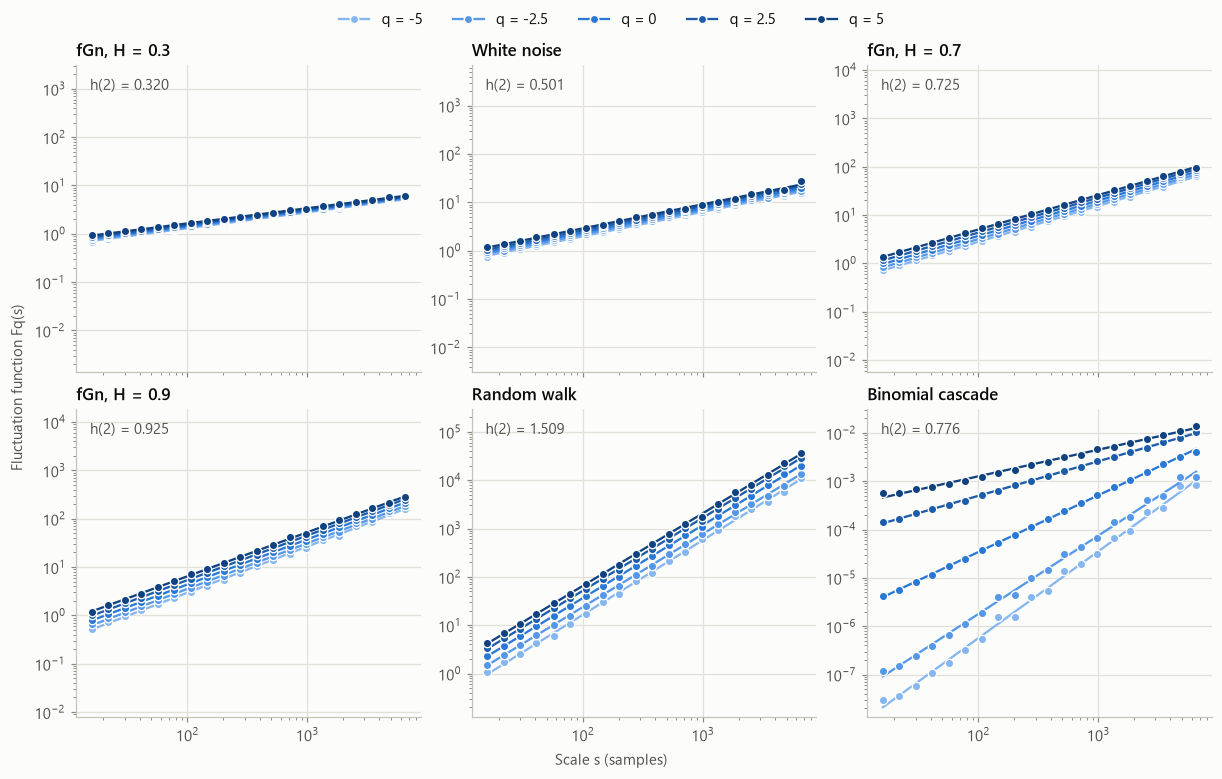

In [4]:
picked = np.unique(np.linspace(0, qs.size - 1, len(Q_RAMP)).round().astype(int))
ramp = Q_RAMP[: picked.size]
low, high = config.fit_range or (scales[0], scales[-1])
fitted = scales[(scales >= low) & (scales <= high)]

log_range = {
    name: (np.log10(result.Fq[picked].min()), np.log10(result.Fq[picked].max()))
    for name, result in results.items()
}
decades = 1.12 * max(top - bottom for bottom, top in log_range.values())

fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, layout="constrained")
for ax, (name, result) in zip(axes.flat, results.items(), strict=True):
    for i, color in zip(picked, ramp, strict=True):
        line = np.exp(result.intercept[i] + result.h[i] * np.log(fitted))
        ax.plot(fitted, line, color=color, lw=1.5)
        ax.plot(scales, result.Fq[i], color=color, **DOT)
    centre = np.mean(log_range[name])
    ax.set(xscale="log", yscale="log")
    ax.set_ylim(10 ** (centre - decades / 2), 10 ** (centre + decades / 2))
    ax.grid(visible=False, which="minor")
    ax.set_title(name)
    h2 = spectrum_features(result, qs)["h2"]
    ax.text(0.04, 0.92, f"h(2) = {h2:.3f}", transform=ax.transAxes, color=INK_SECONDARY)
handles = [
    Line2D([], [], color=color, lw=1.5, marker="o", ms=5.5, mec=SURFACE, label=f"q = {qs[i]:g}")
    for i, color in zip(picked, ramp, strict=True)
]
fig.legend(handles=handles, loc="outside upper center", ncols=len(handles))
fig.supxlabel("Scale s (samples)", color=INK_SECONDARY, fontsize=10)
fig.supylabel("Fluctuation function Fq(s)", color=INK_SECONDARY, fontsize=10)
plt.show()

## Generalised Hurst exponent

Dots are the estimates and grey lines the exact values. The monofractal signals should lie flat
on their lines; the cascade should follow its curve.

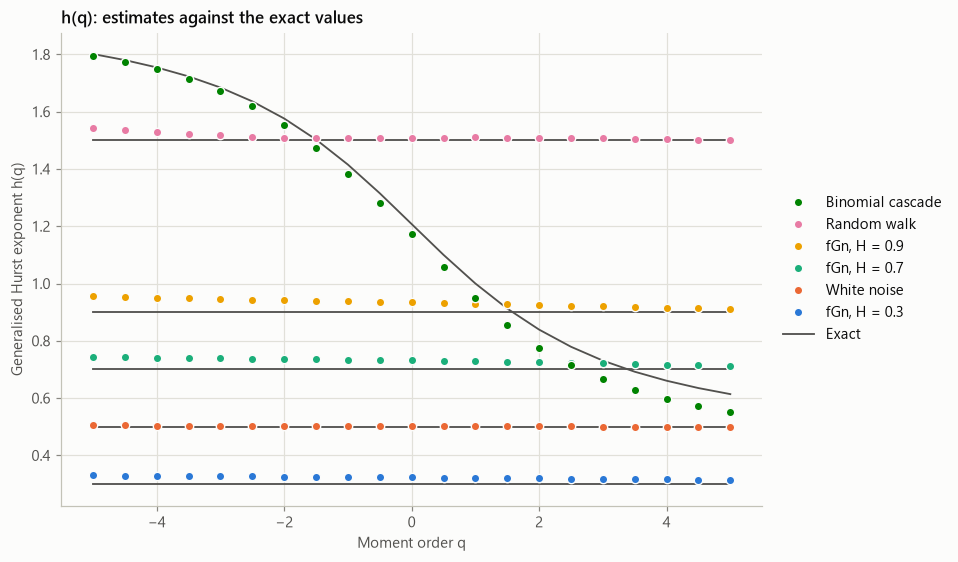

In [5]:
theory_handle = Line2D([], [], color=THEORY, lw=1.2, label="Exact")

fig, ax = plt.subplots(figsize=(8.6, 5), layout="constrained")
for name, result in results.items():
    ax.plot(qs, theory[name][0], color=THEORY, lw=1.2, zorder=1)
    ax.plot(qs, result.h, color=COLOR[name], label=name, zorder=2, **DOT)
ax.set(xlabel="Moment order q", ylabel="Generalised Hurst exponent h(q)")
ax.set_title("h(q): estimates against the exact values")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=[*handles[::-1], theory_handle], loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

## Singularity spectrum

$f(\alpha)$ against $\alpha$, with $\alpha = d\tau/dq$ taken numerically on the $q$ grid. A
monofractal signal should give a tight cluster at its exact point, marked with a cross; the cascade
should trace its arc. The clusters are not points because the estimate of $h(q)$ drifts slightly
with $q$ at finite length.

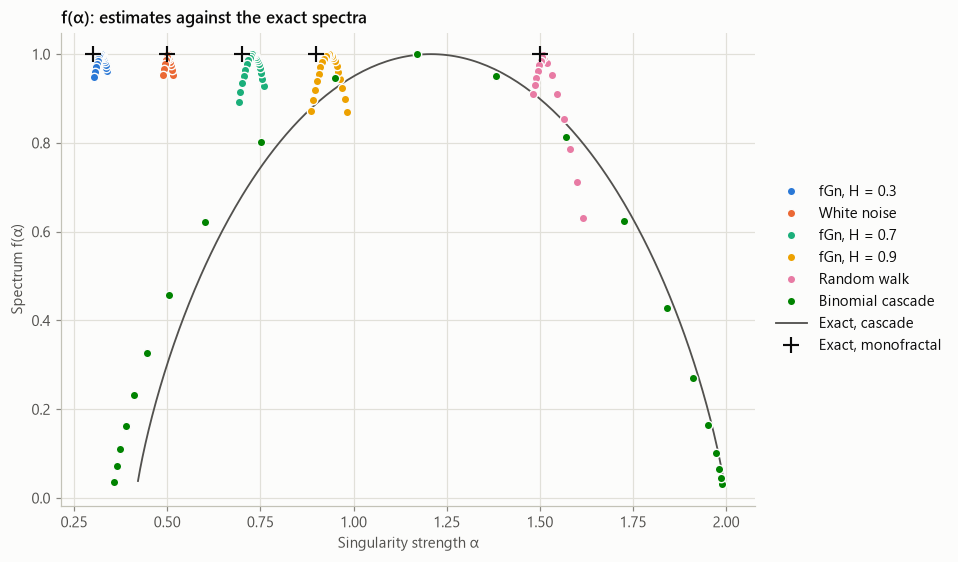

In [6]:
fine_q = np.linspace(qs[0], qs[-1], 401)
_, cascade_alpha, cascade_f = binomial_cascade_spectrum(fine_q, CASCADE_A)

fig, ax = plt.subplots(figsize=(8.6, 5), layout="constrained")
ax.plot(cascade_alpha, cascade_f, color=THEORY, lw=1.2, zorder=1)
for name, result in results.items():
    ax.plot(result.alpha, result.f_alpha, color=COLOR[name], label=name, zorder=2, **DOT)
    if name != "Binomial cascade":
        exact = theory[name][1][0]
        ax.plot(exact, 1.0, marker="+", ms=11, mew=1.4, color=INK, ls="none", zorder=3)
ax.set(xlabel=f"Singularity strength {ALPHA}", ylabel=f"Spectrum f({ALPHA})")
ax.set_title(f"f({ALPHA}): estimates against the exact spectra")
handles, _ = ax.get_legend_handles_labels()
exact_handles = [
    Line2D([], [], color=THEORY, lw=1.2, label="Exact, cascade"),
    Line2D([], [], color=INK, marker="+", ms=11, mew=1.4, ls="none", label="Exact, monofractal"),
]
ax.legend(handles=[*handles, *exact_handles], loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.show()

## Features against theory

The same realisations as numbers. `asymmetry` is only meaningful when the spectrum has a real
width: for the monofractal signals it is the shape of a noise cluster.

In [7]:
rows = []
for name, result in results.items():
    features = spectrum_features(result, qs)
    h_exact, alpha_exact, _ = theory[name]
    rows.append(
        {
            "signal": name,
            "h2": features["h2"],
            "h2 exact": np.interp(2.0, qs, h_exact),
            "delta_h": features["delta_h"],
            "delta_h exact": h_exact[0] - h_exact[-1],
            "delta_alpha": features["delta_alpha"],
            "delta_alpha exact": np.ptp(alpha_exact),
            "alpha0": features["alpha0"],
            "alpha0 exact": np.interp(0.0, qs, alpha_exact),
            "asymmetry": features["asymmetry"],
            "min_r2": features["min_r2"],
        }
    )
display(pd.DataFrame(rows).set_index("signal").round(3))

,h2,h2 exact,delta_h,delta_h exact,delta_alpha,delta_alpha exact,alpha0,alpha0 exact,asymmetry,min_r2
signal,,,,,,,,,,
"fGn, H = 0.3",0.320,0.300,0.015,0.000,0.033,0.000,0.323,0.300,0.103,0.999
White noise,0.501,0.500,0.007,0.000,0.026,0.000,0.501,0.500,-0.029,0.997
"fGn, H = 0.7",0.725,0.700,0.032,0.000,0.067,0.000,0.731,0.700,0.178,0.999
"fGn, H = 0.9",0.925,0.900,0.045,0.000,0.097,0.000,0.934,0.900,0.012,0.999
Random walk,1.509,1.500,0.043,0.000,0.134,0.000,1.508,1.500,-0.624,0.999
Binomial cascade,0.776,0.839,1.246,1.187,1.632,1.572,1.171,1.208,-0.003,0.995


## The cascade and the choice of scales

The cascade is the one signal that is visibly off: $h(q)$ is too low, most of all for positive
$q$. That is a property of the method on this signal, not an error in the code (the PyPI `MFDFA`
package returns the same $F_q$ to 11 digits), and it has two parts.

1. **Small scales.** When the windows coincide with the cascade's dyadic boxes, $F^2(v, s)$ is
   exactly the squared mass of box $v$ times a factor that depends on $s$ alone. The factor only
   approaches a constant as $s$ grows, which bends every $\log F_q$ the same way. So on dyadic
   scales the error in $h(q)$ is the same at every $q$, it shrinks as the fit moves to larger
   scales, and the differences between moment orders ($\Delta h$, the width of the spectrum) are
   exact.
2. **Windows that straddle the boxes.** Log-spaced scales are not powers of two, and the
   fluctuation of a straddling window differs from that of an aligned one by an amount that
   depends on $q$. This is what makes the error vary with $q$ on the configured scales.

The exact width of the spectrum is 1.572; 1.574 is what a finite difference on this $q$ grid gives
for the exact $\tau(q)$.

In [8]:
x = binomial_cascade(N_LEVELS, CASCADE_A)
h_exact = theory["Binomial cascade"][0]
dyadic = 2 ** np.arange(4, N_LEVELS - 2)

rows = []
for label, grid, fit_range in [
    ("configured scales", scales, config.fit_range),
    ("dyadic, fit from 16 samples", dyadic, None),
    ("dyadic, fit from 64 samples", dyadic, (64, dyadic[-1])),
    ("dyadic, fit from 256 samples", dyadic, (256, dyadic[-1])),
]:
    result = analyse(x, grid, fit_range)
    error = result.h - h_exact
    rows.append(
        {
            "scales": label,
            "mean error in h(q)": error.mean(),
            "largest absolute error": np.abs(error).max(),
            "spread of the error over q": np.ptp(error),
            "delta_alpha": spectrum_features(result, qs)["delta_alpha"],
        }
    )
display(pd.DataFrame(rows).set_index("scales").round(4))

,mean error in h(q),largest absolute error,spread of the error over q,delta_alpha
scales,,,,
configured scales,-0.0379,0.0648,0.0595,1.6320
"dyadic, fit from 16 samples",-0.0526,0.0526,0.0000,1.5739
"dyadic, fit from 64 samples",-0.0259,0.0259,0.0000,1.5739
"dyadic, fit from 256 samples",-0.0108,0.0108,0.0000,1.5739


## Accuracy over realisations

Mean and standard deviation of the estimates over 100 realisations of each random signal, at the
length and settings above. This is the table quoted at the top of `tests/test_mfdfa.py`: a test
tolerance there is the bias shown here plus four standard deviations.

In [9]:
N_REALISATIONS = 100
generators = {
    "fGn, H = 0.3": (0.3, lambda rng: fgn(N_SAMPLES, 0.3, rng)),
    "White noise": (0.5, lambda rng: rng.standard_normal(N_SAMPLES)),
    "fGn, H = 0.7": (0.7, lambda rng: fgn(N_SAMPLES, 0.7, rng)),
    "fGn, H = 0.9": (0.9, lambda rng: fgn(N_SAMPLES, 0.9, rng)),
    "Random walk": (1.5, lambda rng: np.cumsum(rng.standard_normal(N_SAMPLES))),
}


def mean_sd(values):
    return f"{np.mean(values):.3f} +- {np.std(values):.3f}"


rows = []
for name, (hurst, generate) in generators.items():
    h, features = [], []
    for seed in range(N_REALISATIONS):
        result = analyse(generate(np.random.default_rng(seed)))
        h.append(result.h)
        features.append(spectrum_features(result, qs))
    h = np.array(h)
    widths = np.array([f["delta_alpha"] for f in features])
    rows.append(
        {
            "signal": name,
            "exact H": hurst,
            f"h({qs[0]:g})": mean_sd(h[:, 0]),
            "h(2)": mean_sd([f["h2"] for f in features]),
            f"h({qs[-1]:g})": mean_sd(h[:, -1]),
            "delta_alpha": mean_sd(widths),
            "largest delta_alpha": widths.max(),
            "lowest min_r2": min(f["min_r2"] for f in features),
        }
    )
display(pd.DataFrame(rows).set_index("signal").round(3))

,exact H,h(-5),h(2),h(5),delta_alpha,largest delta_alpha,lowest min_r2
signal,,,,,,,
"fGn, H = 0.3",0.3,0.310 +- 0.007,0.300 +- 0.008,0.297 +- 0.010,0.030 +- 0.012,0.053,0.991
White noise,0.5,0.510 +- 0.010,0.502 +- 0.010,0.499 +- 0.012,0.033 +- 0.017,0.089,0.994
"fGn, H = 0.7",0.7,0.708 +- 0.014,0.698 +- 0.014,0.692 +- 0.016,0.046 +- 0.021,0.106,0.994
"fGn, H = 0.9",0.9,0.910 +- 0.018,0.897 +- 0.016,0.890 +- 0.019,0.060 +- 0.027,0.133,0.995
Random walk,1.5,1.534 +- 0.027,1.498 +- 0.022,1.489 +- 0.025,0.124 +- 0.040,0.255,0.994


## Reading the results

With the default configuration ($q$ from $-5$ to 5, 20 scales from 16 samples to a tenth of the
length, order 1):

- **Monofractal signals.** $h(2)$ is unbiased to within 0.003 and has a standard deviation of 0.01
  to 0.02 at this length. The estimator leans towards a wider spectrum than the truth: $h(-5)$
  comes out about 0.01 high and $h(5)$ up to 0.01 low (0.03 and 0.01 for the random walk), so a
  monofractal signal shows a $\Delta\alpha$ of 0.03 to 0.06 rather than zero (0.12 for the random
  walk). A $\Delta\alpha$ of that size in real data is not evidence of multifractality.
- **Binomial cascade.** The spectrum is recovered as wide ($\Delta\alpha$ within 4 % of the exact
  value) and symmetric. $h(q)$ itself is low by up to 0.065 on the configured scales, for the
  reasons in the section above; on dyadic scales fitted from 256 samples it is low by 0.011 at
  every $q$.